# Paleo Erosion Calculations (Mataquito Package Integration)

Calculates 10Be decay corrections and paleo-erosion rates for CT-Ter-2 and CT-Ter-10
samples from the coastal terrace outcrop.

**Data sources:**
- Paleo sample data (uncorrected 10Be, erosion rates): `../Mataquito/data/sample_metadata/MataquitoSampleData.xlsx` Sheet2
- Modern sample data (areas, production rates, erosion rates): Sheet1 via `mataquito.sample_data`
- Quartz/zircon fertility distributions: `mataquito` package (NB06 methodology, CT-8/CT-3 → CT-9 scenario)
- Detrital zircon U-Pb data: `Spreadsheets/CT-Ter_ZrUPb_datasheets.xlsx`
- Zircon mixing weights: detritalPy-mix best-fit (see `detritalPy_mix/detritalPy-mix_coastal.ipynb`)

**Corrected paleo concentrations (N_paleo) are computed in this notebook** from the
measured concentrations and Ar-Ar burial ages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

# Add mataquito package to path (one level up from Mataquito_Paleo/)
REPO_ROOT = os.path.dirname(os.getcwd())
MATAQUITO_DIR = os.path.join(REPO_ROOT, 'Mataquito')
sys.path.insert(0, MATAQUITO_DIR)

from mataquito.sample_data import load_samples, get_areas, get_production_rates
from mataquito.erosion import generate_mc_samples, flux_order_samples
from mataquito.fertility import load_wct, quartz_fertility, zircon_fertility

## 1. Load paleo sample data from Sheet2

Sheet2 contains measured (uncorrected) 10Be concentrations, erosion rates computed
from uncorrected concentrations, and sample metadata for CT-Ter-2 and CT-Ter-10.

In [2]:
XLSX_PATH = os.path.join(os.getcwd(), 'MataquitoSampleData.xlsx')
df_paleo = pd.read_excel(XLSX_PATH, sheet_name='Sheet2')

print('Paleo sample data (Sheet2):')
print(df_paleo[['Sample_ID', '10Be_concentration', '10Be_concentration_uncertainty',
                'Virtual_Elevation', 'Erosion_rate',
                'Erosion_rate_uncertainty_internal',
                'Erosion_rate_uncertainty_external']].to_string(index=False))

# Build per-sample lookup
samples_paleo = {}
for _, row in df_paleo.iterrows():
    sid = row['Sample_ID']
    samples_paleo[sid] = {
        'N_measured':       row['10Be_concentration'],
        'N_uncertainty':    row['10Be_concentration_uncertainty'],
        'virtual_elevation': row['Virtual_Elevation'],
    }

Paleo sample data (Sheet2):
Sample_ID  10Be_concentration  10Be_concentration_uncertainty  Virtual_Elevation  Erosion_rate  Erosion_rate_uncertainty_internal  Erosion_rate_uncertainty_external
 CT-Ter-2               51000                             967            1451.47          78.7                               2.80                               6.84
CT-Ter-10              120000                            2250            1451.47          51.8                               2.77                               4.96


## 2. Burial age parameters

Burial ages are from Ar-Ar geochronology of interbedded volcanic ashes in the
coastal terrace sequence.  These are input parameters; they are not yet stored
in the spreadsheet.

In [3]:
burial_ages = {
    'CT-Ter-2':  {'t_Ma': 1.30, 'sigma_Ma': 0.06},   # Ma (Ar-Ar)
    'CT-Ter-10': {'t_Ma': 0.40, 'sigma_Ma': 0.10},   # Ma (Ar-Ar)
}

# Physical constants
lambda_Be10    = 4.997e-7   # yr^-1 (10Be decay constant)
Lambda         = 160.0      # g/cm²  (spallation attenuation length)
rho            = 2.65       # g/cm³  (rock density)
cm_yr_to_m_Myr = 1e4        # unit conversion: cm/yr → m/Myr

print(f'Decay constant (λ): {lambda_Be10:.3e} yr⁻¹')
print(f'Half-life:          {np.log(2)/lambda_Be10/1e6:.3f} Myr')

Decay constant (λ): 4.997e-07 yr⁻¹
Half-life:          1.387 Myr


## 3. Decay correction — compute paleo 10Be concentrations

$$N_0 = N_{\rm meas}\, e^{\lambda t}$$

Relative uncertainty propagation:
$$\frac{\sigma(N_0)}{N_0} = \sqrt{\left(\frac{\sigma_N}{N}\right)^2 + (\lambda\,\sigma_t)^2}$$

In [4]:
print('=' * 70)
print('10Be Paleo Concentration Decay Correction')
print('=' * 70)

paleo_concentrations = {}
for sid, ages in burial_ages.items():
    N_meas  = samples_paleo[sid]['N_measured']
    N_unc   = samples_paleo[sid]['N_uncertainty']
    t_yr    = ages['t_Ma'] * 1e6
    sigma_t = ages['sigma_Ma'] * 1e6

    exp_factor    = np.exp(lambda_Be10 * t_yr)
    N_paleo       = N_meas * exp_factor

    # Relative uncertainty: analytical + age components
    rel_N = N_unc / N_meas
    rel_t = lambda_Be10 * sigma_t
    rel_total = np.sqrt(rel_N**2 + rel_t**2)
    N_paleo_unc = N_paleo * rel_total

    paleo_concentrations[sid] = {
        'N_paleo':     N_paleo,
        'N_paleo_unc': N_paleo_unc,
        'rel_total':   rel_total,
    }

    pct = (N_paleo - N_meas) / N_meas * 100
    print(f'\n{sid}:')
    print(f'  Measured:   {N_meas:.2e} ± {N_unc:.2e} atoms/g')
    print(f'  Burial:     {ages["t_Ma"]:.2f} ± {ages["sigma_Ma"]:.2f} Ma')
    print(f'  Correction: ×{exp_factor:.4f}  ({pct:.1f}% increase)')
    print(f'  N_paleo:    {N_paleo:.2e} ± {N_paleo_unc:.2e} atoms/g  ({rel_total*100:.2f}% total)')
    print(f'    analytical: {rel_N*100:.2f}%   age: {rel_t*100:.2f}%')
    print(f'  → Input to CRONUS: {N_paleo:.2e} ± {N_paleo_unc:.2e} atoms/g')

print('\n' + '=' * 70)

10Be Paleo Concentration Decay Correction

CT-Ter-2:
  Measured:   5.10e+04 ± 9.67e+02 atoms/g
  Burial:     1.30 ± 0.06 Ma
  Correction: ×1.9148  (91.5% increase)
  N_paleo:    9.77e+04 ± 3.46e+03 atoms/g  (3.55% total)
    analytical: 1.90%   age: 3.00%
  → Input to CRONUS: 9.77e+04 ± 3.46e+03 atoms/g

CT-Ter-10:
  Measured:   1.20e+05 ± 2.25e+03 atoms/g
  Burial:     0.40 ± 0.10 Ma
  Correction: ×1.2213  (22.1% increase)
  N_paleo:    1.47e+05 ± 7.82e+03 atoms/g  (5.34% total)
    analytical: 1.88%   age: 5.00%
  → Input to CRONUS: 1.47e+05 ± 7.82e+03 atoms/g



In [5]:
# Load modern sample data (Sheet1) for areas, production rates, and modern erosion rates
df_mat = load_samples()
A = get_areas(df_mat)
P = get_production_rates(df_mat)

In [10]:
paleo_erosion = {}
for _, row in df_paleo.iterrows():
    sid = row['Sample_ID']
    paleo_erosion[sid] = {
        'E_c':     row['Erosion_rate'],
        'sigma_E': row['Erosion_rate_uncertainty_external'],
    }

for sid, v in paleo_erosion.items():
    print(f"{sid}: E_c = {v['E_c']:.2f} ± {v['sigma_E']:.2f} m/Myr")

CT-Ter-2: E_c = 78.70 ± 6.84 m/Myr
CT-Ter-10: E_c = 51.80 ± 4.96 m/Myr


## 4. Paleo mixing parameters

Best-fit zircon mixing weights from detritalPy-mix (vmax metric, 10000 bootstrap
iterations; parents: CT-8.2 + CT-3; children: CT-Ter-2, CT-Ter-10).

- Detrital zircon data: `Spreadsheets/CT-Ter_ZrUPb_datasheets.xlsx`
- Mixing notebook: `detritalPy_mix/detritalPy-mix_coastal.ipynb`

In [11]:
# Sample roles (A = numerator = Principal Cordillera, B = denominator = Coastal)
sample_a_name = 'CT-8'
sample_b_name = 'CT-3'
sample_c_name = 'CT-9'   # Modern mixed reference sample

# Mixing weights from detritalPy-mix best-fit
mixing_weights = {
    'CT-Ter-2':  {'w_A': 0.683, 'w_B': 0.317},   # CT-8.2=0.683, CT-3=0.317
    'CT-Ter-10': {'w_A': 0.655, 'w_B': 0.345},   # CT-8.2=0.655, CT-3=0.345
}

# Monte Carlo parameters
num_samples = 100_000
random_seed = 17
np.random.seed(random_seed)

for sid, wt in mixing_weights.items():
    print(f"{sid}: CT-8.2={wt['w_A']:.3f}, CT-3={wt['w_B']:.3f}")

CT-Ter-2: CT-8.2=0.683, CT-3=0.317
CT-Ter-10: CT-8.2=0.655, CT-3=0.345


## 5. Compute fertility distributions from mataquito (NB06 methodology)

Replicates the CT-8/CT-3 → CT-9 scenario from `06_fertility_analysis.ipynb`:
- Flux-ordered erosion rates (CT-8 ordered vs CT-5 & CT-6, CT-3 independent)
- Adjusted coastal corridor area: $A_{\rm CT3,9} = A_{\rm CT9} - A_{\rm CT8}$
- Bootstrap mixing coefficients from `mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv`

In [33]:
# Flux-ordered erosion rate distributions
N_mc  = 100_000
ER_ext = generate_mc_samples(df_mat, N=N_mc, seed=random_seed)
_fo    = flux_order_samples(ER_ext, A, N=N_mc, seed=random_seed)
CT8_f = _fo['CT8_f']   # CT-8 ordered vs CT-5 & CT-6
CT3_res = _fo['CT3_res']   # CT-3 independent resample

# Areas and production rates
A_A = A[sample_a_name]                          # CT-8 source area (km²)
A_B = A[sample_c_name] - A[sample_a_name]       # coastal corridor: A_CT9 − A_CT8
P_A = P[sample_a_name]
P_B = P[sample_b_name]
P_C = P[sample_c_name]                          # basin-averaged CT-9 production rate

print(f"A_A (CT-8):              {A_A:.1f} km²")
print(f"A_B (coastal corridor):  {A_B:.1f} km²   [A(CT-9) − A(CT-8)]")
print(f"P_A = {P_A:.4f},  P_B = {P_B:.4f},  P_C = {P_C:.4f} atoms/g/yr")
print()

# Bootstrap mixing coefficients for CT-8.2/CT-3 → CT-9
MIX_DIR = os.path.join(MATAQUITO_DIR, 'results', 'mixing_coefficients')
wa_ct9, wb_ct9, nt, nk = load_wct(
    os.path.join(MIX_DIR, 'mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv')
)
print(f"Mixing coefficients loaded: {nk}/{nt} kept after threshold filter")

# Quartz fertility (CT-8/CT-3 → CT-9)
Q_samples, _ = quartz_fertility(
    CT8_f, CT3_res, ER_ext[sample_c_name],
    A_A, A_B, A[sample_c_name],
    P_A, P_B, P_C
)

# Zircon fertility (CT-8.2/CT-3 → CT-9)
M = 10_000
zr_result = zircon_fertility(wa_ct9, wb_ct9, CT8_f[:M], CT3_res[:M], A_A, A_B, M)
Z_samples  = zr_result['ZA_ZB']['samples']

# Summary
logQ = np.log10(Q_samples)
r    = zr_result['ZA_ZB']

print("Fertility (CT-8/CT-3 → CT-9):")
print(f"{'Scenario':<25} {'Linear med':>11} {'Linear IQR':>18} {'log10 med':>10} {'log10 IQR':>18}")
print("-"*80)

# Quartz Qa/Qb
lmed = np.median(logQ)
l25, l75 = np.percentile(logQ, [25, 75])
print(f"{'Qa/Qb (CT-8/CT-3→CT-9)':<25} {10**lmed:>11.4f} ({10**l25:.4f} - {10**l75:.4f})   {lmed:>10.4f} ({l25:.4f} - {l75:.4f})")

# Quartz Qb/Qa (inverse)
print(f"{'Qb/Qa (inverse)':<25} {10**-lmed:>11.4f} ({10**-l75:.4f} - {10**-l25:.4f})   {-lmed:>10.4f} ({-l75:.4f} - {-l25:.4f})")

# Zircon ZA/ZB
print(f"{'ZA/ZB (CT-8/CT-3→CT-9)':<25} {r['median']:>11.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>10.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

# Zircon ZB/ZA (inverse)
zlog_inv = -np.log10(Z_samples)
zmed_inv = np.median(zlog_inv)
z25_inv, z75_inv = np.percentile(zlog_inv, [25, 75])
print(f"{'ZB/ZA (inverse)':<25} {10**zmed_inv:>11.4f} ({10**z25_inv:.4f} - {10**z75_inv:.4f})   {zmed_inv:>10.4f} ({z25_inv:.4f} - {z75_inv:.4f})")

A_A (CT-8):              4950.4 km²
A_B (coastal corridor):  1239.3 km²   [A(CT-9) − A(CT-8)]
P_A = 14.4453,  P_B = 5.5128,  P_C = 12.5239 atoms/g/yr

Mixing coefficients loaded: 9983/10000 kept after threshold filter
Fertility (CT-8/CT-3 → CT-9):
Scenario                   Linear med         Linear IQR  log10 med          log10 IQR
--------------------------------------------------------------------------------
Qa/Qb (CT-8/CT-3→CT-9)         0.0295 (0.0228 - 0.0375)      -1.5300 (-1.6428 - -1.4261)
Qb/Qa (inverse)               33.8858 (26.6765 - 43.9379)       1.5300 (1.4261 - 1.6428)
ZA/ZB (CT-8/CT-3→CT-9)         0.1849 (0.1286 - 0.2795)      -0.7331 (-0.8907 - -0.5537)
ZB/ZA (inverse)                5.4092 (3.5783 - 7.7754)       0.7331 (0.5537 - 0.8907)


## 6. Solve for paleo erosion rates

System of equations using quartz fertility ($Q_A/Q_B$) and zircon fertility
($Z_A/Z_B$) to decompose the mixed-sample erosion rate $E_c$ into principal
cordillera ($E_A$) and coastal cordillera ($E_B$) components.

In [34]:
def solve_paleo(E_c_mean, E_c_std, w_A, w_B, sample_name):
    """Monte Carlo solve for paleo E_A (CT-8) and E_B (CT-3).

    Parameters
    ----------
    E_c_mean, E_c_std : float
        Paleo bulk erosion rate and 1-sigma uncertainty (m/Myr).
    w_A, w_B : float
        Zircon mixing weights for sample A (CT-8.2) and B (CT-3) from detritalPy-mix.
    sample_name : str
        Label for output.
    """
    # Sample E_c and resample fertility distributions
    E_c     = np.random.normal(E_c_mean, E_c_std, size=num_samples)
    Q_ratio = np.random.choice(Q_samples, size=num_samples, replace=True)
    Z_ratio = np.random.choice(Z_samples, size=num_samples, replace=True)

    E_A_sols = np.full(num_samples, np.nan)
    E_B_sols = np.full(num_samples, np.nan)

    for i in range(num_samples):
        # From zircon mixing: E_B = k * E_A
        k   = Z_ratio[i] * (w_B / w_A) * (A_A / A_B)
        num = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
        den = P_C  * (Q_ratio[i] * A_A + A_B * k)
        if den > 0 and num > 0:
            E_A_sols[i] = num / den
            E_B_sols[i] = k * E_A_sols[i]

    # Show first valid solution as a worked example
    i = 0
    k_ex   = Z_ratio[i] * (w_B / w_A) * (A_A / A_B)
    num_ex = E_c[i] * (A_B * P_B + Q_ratio[i] * A_A * P_A)
    den_ex = P_C * (Q_ratio[i] * A_A + A_B * k_ex)
    E_A_ex = num_ex / den_ex
    E_B_ex = k_ex * E_A_ex
    
    print(f"\n--- Example solution (iteration 0) for {sample_name} ---")
    print(f"k    = {Z_ratio[i]:.4f} * ({w_B:.3f}/{w_A:.3f}) * ({A_A:.1f}/{A_B:.1f}) = {k_ex:.4f}")
    print(f"E_c  = {E_c[i]:.2f} m/Myr")
    print(f"Q    = {Q_ratio[i]:.4f}")
    print(f"num  = {E_c[i]:.2f} * ({A_B:.1f}*{P_B:.4f} + {Q_ratio[i]:.4f}*{A_A:.1f}*{P_A:.4f}) = {num_ex:.2f}")
    print(f"den  = {P_C:.4f} * ({Q_ratio[i]:.4f}*{A_A:.1f} + {A_B:.1f}*{k_ex:.4f}) = {den_ex:.2f}")
    print(f"E_A  = {num_ex:.2f} / {den_ex:.2f} = {E_A_ex:.2f} m/Myr")
    print(f"E_B  = {k_ex:.4f} * {E_A_ex:.2f} = {E_B_ex:.2f} m/Myr")
    print(f"------------------------------------------------------")

    valid  = np.isfinite(E_A_sols) & (E_A_sols > 0) & (E_B_sols > 0)
    E_A_v  = E_A_sols[valid]
    E_B_v  = E_B_sols[valid]

    print(f"\n{sample_name}  (E_c = {E_c_mean:.1f} ± {E_c_std:.1f} m/Myr):")
    print(f"  E_A ({sample_a_name}): {np.median(E_A_v):.2f}  "
          f"({np.percentile(E_A_v,25):.2f}–{np.percentile(E_A_v,75):.2f}) m/Myr")
    print(f"  E_B ({sample_b_name}): {np.median(E_B_v):.2f}  "
          f"({np.percentile(E_B_v,25):.2f}–{np.percentile(E_B_v,75):.2f}) m/Myr")
    print(f"  Valid solutions: {valid.sum()}/{num_samples} ({100*valid.mean():.1f}%)")

    return {
        'E_A_median': np.median(E_A_v),
        'E_B_median': np.median(E_B_v),
        'E_A_p25':    np.percentile(E_A_v, 25),
        'E_A_p75':    np.percentile(E_A_v, 75),
        'E_B_p25':    np.percentile(E_B_v, 25),
        'E_B_p75':    np.percentile(E_B_v, 75),
        'E_A_samples': E_A_v,
        'E_B_samples': E_B_v,
    }


print("PALEO EROSION RATES")
results = {}
for sid in ['CT-Ter-2', 'CT-Ter-10']:
    results[sid] = solve_paleo(
        paleo_erosion[sid]['E_c'],
        paleo_erosion[sid]['sigma_E'],
        mixing_weights[sid]['w_A'],
        mixing_weights[sid]['w_B'],
        sid,
    )
    results[sid]['t_Ma'] = burial_ages[sid]['t_Ma']

PALEO EROSION RATES

--- Example solution (iteration 0) for CT-Ter-2 ---
k    = 0.4379 * (0.317/0.683) * (4950.4/1239.3) = 0.8119
E_c  = 63.41 m/Myr
Q    = 0.0256
num  = 63.41 * (1239.3*5.5128 + 0.0256*4950.4*14.4453) = 549077.91
den  = 12.5239 * (0.0256*4950.4 + 1239.3*0.8119) = 14185.92
E_A  = 549077.91 / 14185.92 = 38.71 m/Myr
E_B  = 0.8119 * 38.71 = 31.42 m/Myr
------------------------------------------------------

CT-Ter-2  (E_c = 78.7 ± 6.8 m/Myr):
  E_A (CT-8): 97.85  (70.73–126.48) m/Myr
  E_B (CT-3): 33.51  (29.86–37.24) m/Myr
  Valid solutions: 100000/100000 (100.0%)

--- Example solution (iteration 0) for CT-Ter-10 ---
k    = 0.1451 * (0.345/0.655) * (4950.4/1239.3) = 0.3052
E_c  = 51.06 m/Myr
Q    = 0.0430
num  = 51.06 * (1239.3*5.5128 + 0.0430*4950.4*14.4453) = 505913.35
den  = 12.5239 * (0.0430*4950.4 + 1239.3*0.3052) = 7403.34
E_A  = 505913.35 / 7403.34 = 68.34 m/Myr
E_B  = 0.3052 * 68.34 = 20.85 m/Myr
------------------------------------------------------

CT-Ter-10  (

## 7. Plot erosion rate history

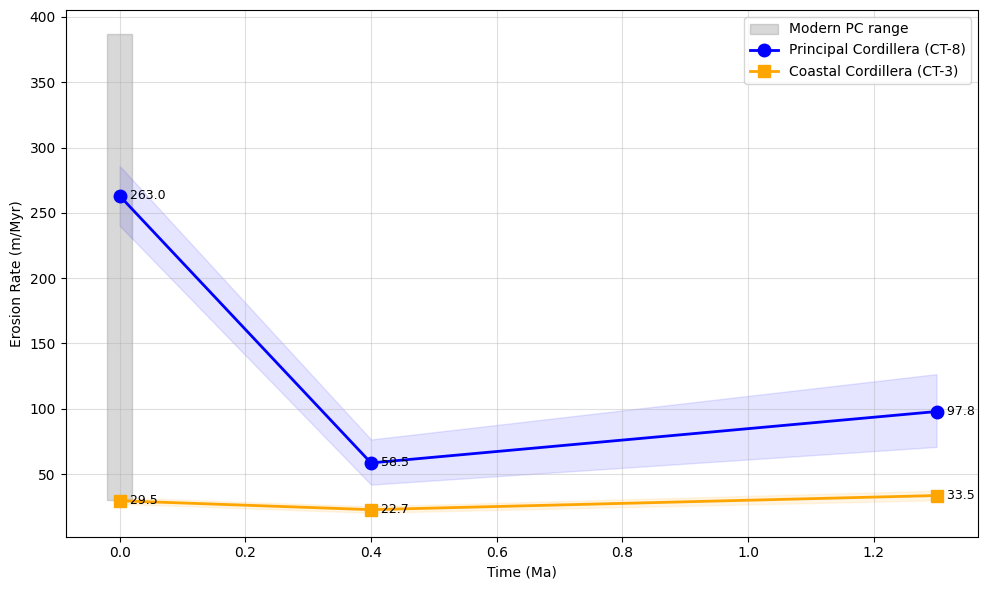


Principal Cordillera (CT-8):
 Time (Ma)     Median      p25      p75
      1.30       97.8     70.7    126.5
      0.40       58.5     41.9     76.4
      0.00      263.0    240.1    285.9

Coastal Cordillera (CT-3):
 Time (Ma)     Median      p25      p75
      1.30       33.5     29.9     37.2
      0.40       22.7     20.3     25.2
      0.00       29.5     27.1     31.9


In [35]:
# Modern erosion rates from Sheet1
modern_E_A     = df_mat.loc[df_mat['Sample_ID'] == sample_a_name, 'Erosion_rate'].values[0]
modern_E_A_std = df_mat.loc[df_mat['Sample_ID'] == sample_a_name,
                            'Erosion_rate_uncertainty_external'].values[0]
modern_E_B     = df_mat.loc[df_mat['Sample_ID'] == sample_b_name, 'Erosion_rate'].values[0]
modern_E_B_std = df_mat.loc[df_mat['Sample_ID'] == sample_b_name,
                            'Erosion_rate_uncertainty_external'].values[0]

# Time series: CT-Ter-2, CT-Ter-10, modern
ter2, ter10 = results['CT-Ter-2'], results['CT-Ter-10']
times   = [ter2['t_Ma'],     ter10['t_Ma'],     0.0]

E_A_med = [ter2['E_A_median'],  ter10['E_A_median'],  modern_E_A]
E_A_lo  = [ter2['E_A_p25'],     ter10['E_A_p25'],     modern_E_A - modern_E_A_std]
E_A_hi  = [ter2['E_A_p75'],     ter10['E_A_p75'],     modern_E_A + modern_E_A_std]

E_B_med = [ter2['E_B_median'],  ter10['E_B_median'],  modern_E_B]
E_B_lo  = [ter2['E_B_p25'],     ter10['E_B_p25'],     modern_E_B - modern_E_B_std]
E_B_hi  = [ter2['E_B_p75'],     ter10['E_B_p75'],     modern_E_B + modern_E_B_std]

fig, ax = plt.subplots(figsize=(10, 6))

# Modern PC range (grey band)
ax.fill_between([-0.02, 0.02], 29.8, 387, color='grey', alpha=0.3,
                label='Modern PC range', zorder=0)

# IQR envelopes
ax.fill_between(times, E_A_lo, E_A_hi, color='blue',   alpha=0.1, zorder=1)
ax.fill_between(times, E_B_lo, E_B_hi, color='orange', alpha=0.1, zorder=1)

# Median lines + markers
ax.plot(times, E_A_med, '-o', color='blue',   markersize=9, linewidth=2,
        label=f'Principal Cordillera ({sample_a_name})', zorder=3)
ax.plot(times, E_B_med, '-s', color='orange', markersize=9, linewidth=2,
        label=f'Coastal Cordillera ({sample_b_name})',   zorder=3)

# Value labels
offset = 0.01
for t, v in zip(times, E_A_med):
    ax.text(t + offset, v, f' {v:.1f}', va='center', ha='left', fontsize=9)
for t, v in zip(times, E_B_med):
    ax.text(t + offset, v, f' {v:.1f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
ax.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Numeric summary
print('\nPrincipal Cordillera (CT-8):')
print(f'{"Time (Ma)":>10} {"Median":>10} {"p25":>8} {"p75":>8}')
for t, med, lo, hi in zip(times, E_A_med, E_A_lo, E_A_hi):
    print(f'{t:>10.2f} {med:>10.1f} {lo:>8.1f} {hi:>8.1f}')

print('\nCoastal Cordillera (CT-3):')
print(f'{"Time (Ma)":>10} {"Median":>10} {"p25":>8} {"p75":>8}')
for t, med, lo, hi in zip(times, E_B_med, E_B_lo, E_B_hi):
    print(f'{t:>10.2f} {med:>10.1f} {lo:>8.1f} {hi:>8.1f}')

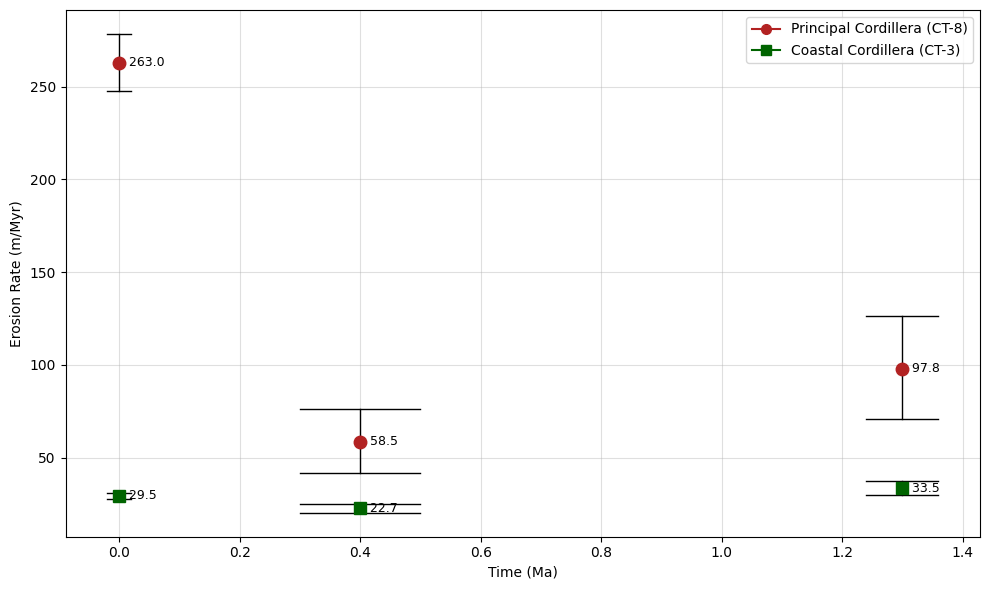

In [36]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 6))

for t, E_A, E_B, key in plot_data:
    w = age_err[key]
    for samples, color, marker in [(E_A, 'firebrick', 'o'), (E_B, 'darkgreen', 's')]:
        med = np.median(samples)
        p25 = np.percentile(samples, 25)
        p75 = np.percentile(samples, 75)
        ax.plot([t, t], [p25, p75], color='black', linewidth=1, zorder=2)
        ax.plot([t - w, t + w], [p25, p25], color='black', linewidth=1, zorder=3)
        ax.plot([t - w, t + w], [p75, p75], color='black', linewidth=1, zorder=3)
        ax.plot(t, med, marker=marker, color=color, markersize=9, zorder=4)

# Value labels
offset = 0.01
for t, v in zip(times, E_A_med):
    ax.text(t + offset, v, f' {v:.1f}', va='center', ha='left', fontsize=9)
for t, v in zip(times, E_B_med):
    ax.text(t + offset, v, f' {v:.1f}', va='center', ha='left', fontsize=9)

ax.legend(handles=[
    Line2D([0], [0], color='firebrick',   linewidth=1.5, marker='o', markersize=7, label=f'Principal Cordillera ({sample_a_name})'),
    Line2D([0], [0], color='darkgreen', linewidth=1.5, marker='s', markersize=7, label=f'Coastal Cordillera ({sample_b_name})'),
])
ax.set_xlabel('Time (Ma)')
ax.set_ylabel('Erosion Rate (m/Myr)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [38]:
fig.savefig('paleo_erosion_vs_time_mataquito.svg', dpi=150, bbox_inches='tight')